# Gene Expression Algorithm (GEA) for Next-Day Stock Forecasting

This notebook implements a simplified **Gene Expression Programming (GEP)-style evolutionary algorithm** to forecast the **next trading day's closing price** for a stock.

It uses real market data pulled from `yfinance`, engineers technical indicators, evolves mathematical forecast expressions, and plots:

- Actual close price
- Predicted close price for each day
- Test-period forecast vs actual close

> **Important:** This is an educational research notebook, not financial advice. Financial markets are noisy, and evolutionary models can overfit historical data very easily.


## 1. Install dependencies

Run this once if needed.


In [ ]:
# !pip install yfinance pandas numpy matplotlib scikit-learn

## 2. Imports and configuration

Change `TICKER`, date range, and population settings below.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

# -----------------------------
# CONFIGURATION
# -----------------------------
TICKER = "AAPL"          # Try: "AAPL", "TSLA", "INFY.NS", "RELIANCE.NS", "^NSEI"
START_DATE = "2006-01-01"
END_DATE = None                  # None means today

POP_SIZE = 80
GENERATIONS = 45
TOURNAMENT_SIZE = 4
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.25
ELITE_COUNT = 5

TEST_SIZE = 0.3                  # Last 20% of data is used for testing

print(f"Ticker selected: {TICKER}")

Ticker selected: AAPL


## 3. Download real stock data from Yahoo Finance

`yfinance.download()` pulls historical OHLCV data.

- `Close`: adjusted closing price
- `Volume`: number of shares traded
- `High`, `Low`, `Open`: daily price extremes


In [ ]:
df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

if df.empty:
    raise ValueError(
        f"No data returned for {TICKER}. Check the ticker symbol, internet connection, or date range."
    )

# yfinance sometimes returns MultiIndex columns; flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

df = df.dropna()
df.index = pd.to_datetime(df.index)

print(df.shape)
df.head()

(5220, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2006-01-03,2.235745,2.235745,2.160971,2.164859,807234400
2006-01-04,2.242326,2.272534,2.228268,2.247111,619603600
2006-01-05,2.224678,2.240231,2.205835,2.238137,449422400
2006-01-06,2.282105,2.294069,2.229763,2.250700,704457600
2006-01-09,2.274627,2.309024,2.265356,2.294966,675040800


## 4. Create technical features

The GEA will use these indicators as inputs:

- Lagged close prices
- Daily return
- Moving averages
- RSI
- MACD
- Bollinger Band position
- Volatility
- Volume change

The target is the **next day's close price**.


In [ ]:
def add_technical_features(data):
    out = data.copy()

    out["Return_1d"] = out["Close"].pct_change()
    out["Return_5d"] = out["Close"].pct_change(5)

    out["MA_5"] = out["Close"].rolling(5).mean()
    out["MA_10"] = out["Close"].rolling(10).mean()
    out["MA_20"] = out["Close"].rolling(20).mean()

    out["Close_to_MA5"] = out["Close"] / out["MA_5"] - 1
    out["Close_to_MA20"] = out["Close"] / out["MA_20"] - 1

    # RSI-14
    delta = out["Close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-10)
    out["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema_12 = out["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = out["Close"].ewm(span=26, adjust=False).mean()
    out["MACD"] = ema_12 - ema_26
    out["MACD_Signal"] = out["MACD"].ewm(span=9, adjust=False).mean()
    out["MACD_Hist"] = out["MACD"] - out["MACD_Signal"]

    # Bollinger Bands
    std_20 = out["Close"].rolling(20).std()
    upper = out["MA_20"] + 2 * std_20
    lower = out["MA_20"] - 2 * std_20
    out["BB_Position"] = (out["Close" ] - lower) / (upper - lower + 1e-10)

    # Volatility
    out["Volatility_10"] = out["Return_1d"].rolling(10).std()
    out["Volatility_20"] = out["Return_1d"].rolling(20).std()

    # Volume
    out["Volume_MA_10"] = out["Volume"].rolling(10).mean()
    out["Volume_Change"] = out["Volume"] / (out["Volume"].shift(1) + 1e-10) - 1

    # Target: next-day close
    out["Target_Close_Next_Day"] = out["Close"].shift(-1)

    return out

df = add_technical_features(df)
# Replace inf and -inf values with NaN, then drop them
df = df.replace([np.inf, -np.inf], np.nan).dropna()

FEATURES = [
    "Close", "Open", "High", "Low", "Volume",
    "Return_1d", "Return_5d",
    "MA_5", "MA_10", "MA_20",
    "Close_to_MA5", "Close_to_MA20",
    "RSI_14", "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Position", "Volatility_10", "Volatility_20",
    "Volume_MA_10", "Volume_Change"
]

X = df[FEATURES].values.astype(float)
y = df["Target_Close_Next_Day"].values.astype(float)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
df[["Close", "Target_Close_Next_Day", "RSI_14", "MACD"]].tail()

Feature matrix shape: (5199, 21)
Target shape: (5199,)


,Close,Target_Close_Next_Day,RSI_14,MACD
Date,,,,
2026-09-25,341.070007,338.399994,74.398735,6.230033
2026-09-28,338.399994,329.399994,76.304562,6.096412
2026-09-29,329.399994,333.019989,63.981709,5.204299
2026-09-30,333.019989,330.320007,57.557990,4.734817
2026-10-01,330.320007,333.690002,47.542243,4.097648


## 5. Train/test split and scaling

We use a chronological split:

- First 80%: training data
- Last 20%: unseen test data

We **do not shuffle** time-series data because future information must not leak into the past.


In [ ]:
split_index = int(len(X) * (1 - TEST_SIZE))

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

dates_train = df.index[:split_index]
dates_test = df.index[split_index:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 3639
Testing samples: 1560


## 6. GEA representation

Each individual is a linear genome made of genes.

Each gene is a small mathematical expression built from:

- Input features
- Constants
- Operators: `+`, `-`, `*`, protected division
- Functions: `abs`, `sqrt`, `tanh`, `min`, `max`

The genome is decoded into a forecast expression tree. Its output predicts the next day's close price.

This is a simplified GEP-style implementation: it keeps the key ideas of **linear genomes, expression decoding, selection, crossover, mutation, and fitness-based evolution**.


In [ ]:
FEATURE_INDICES = list(range(X_train_scaled.shape[1]))

OPERATORS = ["add", "sub", "mul", "div"]
UNARY_FUNCTIONS = ["abs", "sqrt", "tanh", "min", "max"]

GENES_PER_INDIVIDUAL = 6
MAX_TREE_DEPTH = 3

def random_leaf():
    if np.random.rand() < 0.75:
        return ("feature", np.random.choice(FEATURE_INDICES))
    return ("constant", float(np.random.uniform(-1, 1)))

def random_tree(depth=MAX_TREE_DEPTH):
    if depth == 0 or np.random.rand() < 0.25:
        return random_leaf()

    node_type = np.random.choice(["binary", "unary"], p=[0.7, 0.3])

    if node_type == "binary":
        return (
            "binary",
            np.random.choice(OPERATORS),
            random_tree(depth - 1),
            random_tree(depth - 1)
        )

    return (
        "unary",
        np.random.choice(UNARY_FUNCTIONS),
        random_tree(depth - 1)
    )

def random_individual():
    return {
        "genes": [random_tree() for _ in range(GENES_PER_INDIVIDUAL)],
        "gene_weights": np.random.uniform(-1, 1, GENES_PER_INDIVIDUAL),
        "bias": float(np.random.uniform(-1, 1))
    }

def protected_divide(a, b):
    return a / (b + 1e-8)

def evaluate_tree(tree, X_batch):
    kind = tree[0]

    if kind == "feature":
        return X_batch[:, tree[1]]

    if kind == "constant":
        return np.full(X_batch.shape[0], tree[1])

    if kind == "binary":
        op = tree[1]
        left = evaluate_tree(tree[2], X_batch)
        right = evaluate_tree(tree[3], X_batch)

        if op == "add":
            return left + right
        if op == "sub":
            return left - right
        if op == "mul":
            return left * right
        if op == "div":
            return protected_divide(left, right)

    if kind == "unary":
        func = tree[1]
        value = evaluate_tree(tree[2], X_batch)

        if func == "abs":
            return np.abs(value)
        if func == "sqrt":
            return np.sqrt(np.abs(value))
        if func == "tanh":
            return np.tanh(value)
        if func == "min":
            return np.minimum(value, 0)
        if func == "max":
            return np.maximum(value, 0)

    raise ValueError("Unknown tree node")

## 7. Decode genome into prediction

Each gene produces an intermediate signal. The individual combines gene outputs using learned weights and a bias.

Because the target is an actual stock price, we add a simple **last-known-close adjustment**:

\[
\hat{Close}_{t+1} = Close_t + 	ext{predicted return adjustment}
\]

This makes the model predict a realistic next-day price instead of producing arbitrary values.


In [ ]:
def predict_individual(individual, X_batch, last_close):
    gene_outputs = []

    for gene in individual["genes"]:
        gene_outputs.append(evaluate_tree(gene, X_batch))

    gene_outputs = np.vstack(gene_outputs)
    raw_output = individual["gene_weights"] @ gene_outputs + individual["bias"]

    # Convert model output into a bounded next-day return adjustment
    predicted_return_adjustment = 0.02 * np.tanh(raw_output)

    return last_close * (1 + predicted_return_adjustment)

def fitness_score(individual, X_batch, y_true, last_close):
    y_pred = predict_individual(individual, X_batch, last_close)

    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))

    # Lower error is better; use inverse MSE as fitness
    return 1.0 / (mse + 1e-8), mse, mae

## 8. Genetic operators

- **Tournament selection:** choose several random individuals and select the best.
- **Crossover:** exchange genes and weights between two parents.
- **Mutation:** randomly alter genes, weights, or bias.
- **Elitism:** preserve the best individuals each generation.


In [ ]:
def tournament_select(population, fitness_values):
    contenders = np.random.choice(len(population), TOURNAMENT_SIZE, replace=False)
    best_index = contenders[np.argmax(fitness_values[contenders])]
    return population[best_index]

def copy_tree(tree):
    if tree[0] in ["feature", "constant"]:
        return tree

    if tree[0] == "binary":
        return ("binary", tree[1], copy_tree(tree[2]), copy_tree(tree[3]))

    return ("unary", tree[1], copy_tree(tree[2]))

def crossover(parent_a, parent_b):
    if np.random.rand() > CROSSOVER_RATE:
        return parent_a.copy(), parent_b.copy()

    child_a = {
        "genes": [],
        "gene_weights": parent_a["gene_weights"].copy(),
        "bias": parent_a["bias"]
    }

    child_b = {
        "genes": [],
        "gene_weights": parent_b["gene_weights"].copy(),
        "bias": parent_b["bias"]
    }

    for i in range(GENES_PER_INDIVIDUAL):
        if np.random.rand() < 0.5:
            child_a["genes"].append(copy_tree(parent_a["genes"][i]))
            child_b["genes"].append(copy_tree(parent_b["genes"][i]))
        else:
            child_a["genes"].append(copy_tree(parent_b["genes"][i]))
            child_b["genes"].append(copy_tree(parent_a["genes"][i]))

            child_a["gene_weights"][i] = parent_b["gene_weights"][i]
            child_b["gene_weights"][i] = parent_a["gene_weights"][i]

    if np.random.rand() < 0.5:
        child_a["bias"], child_b["bias"] = child_b["bias"], child_a["bias"]

    return child_a, child_b

def mutate_tree(tree, mutation_probability=0.2):
    if np.random.rand() < mutation_probability:
        return random_tree()

    if tree[0] == "feature":
        return tree

    if tree[0] == "constant":
        if np.random.rand() < 0.5:
            return ("constant", tree[1] + np.random.normal(0, 0.1))
        return tree

    if tree[0] == "binary":
        return (
            "binary",
            tree[1] if np.random.rand() > 0.1 else np.random.choice(OPERATORS),
            mutate_tree(tree[2], mutation_probability),
            mutate_tree(tree[3], mutation_probability)
        )

    return (
        "unary",
        tree[1] if np.random.rand() > 0.1 else np.random.choice(UNARY_FUNCTIONS),
        mutate_tree(tree[2], mutation_probability)
    )

def mutate(individual):
    for i in range(GENES_PER_INDIVIDUAL):
        if np.random.rand() < MUTATION_RATE:
            individual["genes"][i] = mutate_tree(individual["genes"][i])

        if np.random.rand() < MUTATION_RATE:
            individual["gene_weights"][i] += np.random.normal(0, 0.1)

    if np.random.rand() < MUTATION_RATE:
        individual["bias"] += np.random.normal(0, 0.1)

    return individual

## 9. Run the GEA

The last close price before each target day is used as the base for the next-day price prediction.


In [ ]:
population = [random_individual() for _ in range(POP_SIZE)]

history = []

for generation in range(GENERATIONS):
    fitness_values = np.zeros(len(population))
    mse_values = np.zeros(len(population))
    mae_values = np.zeros(len(population))

    for i, individual in enumerate(population):
        fitness_values[i], mse_values[i], mae_values[i] = fitness_score(
            individual,
            X_train_scaled,
            y_train,
            df["Close"].values[:split_index]
        )

    best_index = np.argmax(fitness_values)
    best_individual = population[best_index]

    history.append({
        "generation": generation + 1,
        "best_fitness": fitness_values[best_index],
        "best_mse": mse_values[best_index],
        "best_mae": mae_values[best_index]
    })

    if (generation + 1) % 10 == 0 or generation == 0:
        print(
            f"Generation {generation + 1:03d} | "
            f"Train MSE: {mse_values[best_index]:.4f} | "
            f"Train MAE: {mae_values[best_index]:.4f}"
        )

    # Elitism
    elite_indices = np.argsort(fitness_values)[-ELITE_COUNT:]
    next_population = [population[i] for i in elite_indices]

    # Create children
    while len(next_population) < POP_SIZE:
        parent_a = tournament_select(population, fitness_values)
        parent_b = tournament_select(population, fitness_values)

        child_a, child_b = crossover(parent_a, parent_b)

        next_population.append(mutate(child_a))

        if len(next_population) < POP_SIZE:
            next_population.append(mutate(child_b))

    population = next_population

history_df = pd.DataFrame(history)
history_df

Generation 001 | Train MSE: 0.3785 | Train MAE: 0.3337
Generation 010 | Train MSE: 0.3065 | Train MAE: 0.2736
Generation 020 | Train MSE: 0.3057 | Train MAE: 0.2734
Generation 030 | Train MSE: 0.3047 | Train MAE: 0.2749
Generation 040 | Train MSE: 0.3031 | Train MAE: 0.2715


,generation,best_fitness,best_mse,best_mae
0,1,2.641748,0.378537,0.333720
1,2,2.675706,0.373733,0.316471
2,3,2.831400,0.353182,0.311845
3,4,2.831400,0.353182,0.311845
4,5,3.139576,0.318514,0.283533
5,6,3.139576,0.318514,0.283533
6,7,3.222206,0.310346,0.277298
7,8,3.222206,0.310346,0.277298
8,9,3.221576,0.310407,0.278506
9,10,3.262528,0.306511,0.273565


## 10. Evaluate on unseen test data

The best individual is now evaluated on the final 20% of the time series.


In [ ]:
fitness_values = np.zeros(len(population))

for i, individual in enumerate(population):
    fitness_values[i], _, _ = fitness_score(
        individual,
        X_train_scaled,
        y_train,
        df["Close"].values[:split_index]
    )

best_individual = population[np.argmax(fitness_values)]

train_predictions = predict_individual(
    best_individual,
    X_train_scaled,
    df["Close"].values[:split_index]
)

test_predictions = predict_individual(
    best_individual,
    X_test_scaled,
    df["Close"].values[split_index - 1:-1]
)

train_mse = mean_squared_error(y_train, train_predictions)
train_mae = mean_absolute_error(y_train, train_predictions)
train_r2 = r2_score(y_train, train_predictions)

test_mse = mean_squared_error(y_test, test_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)

results = pd.DataFrame({
    "Metric": ["MSE", "MAE", "R2 Score"],
    "Train": [train_mse, train_mae, train_r2],
    "Test": [test_mse, test_mae, test_r2]
})

results

,Metric,Train,Test
0,MSE,0.303177,25.067577
1,MAE,0.273051,3.537760
2,R2 Score,0.999100,0.991981


## 11. Plot actual vs predicted close price

The first plot shows the complete close-price history.

The second plot shows the GEA's predicted next-day close versus the actual next-day close on the unseen test period.


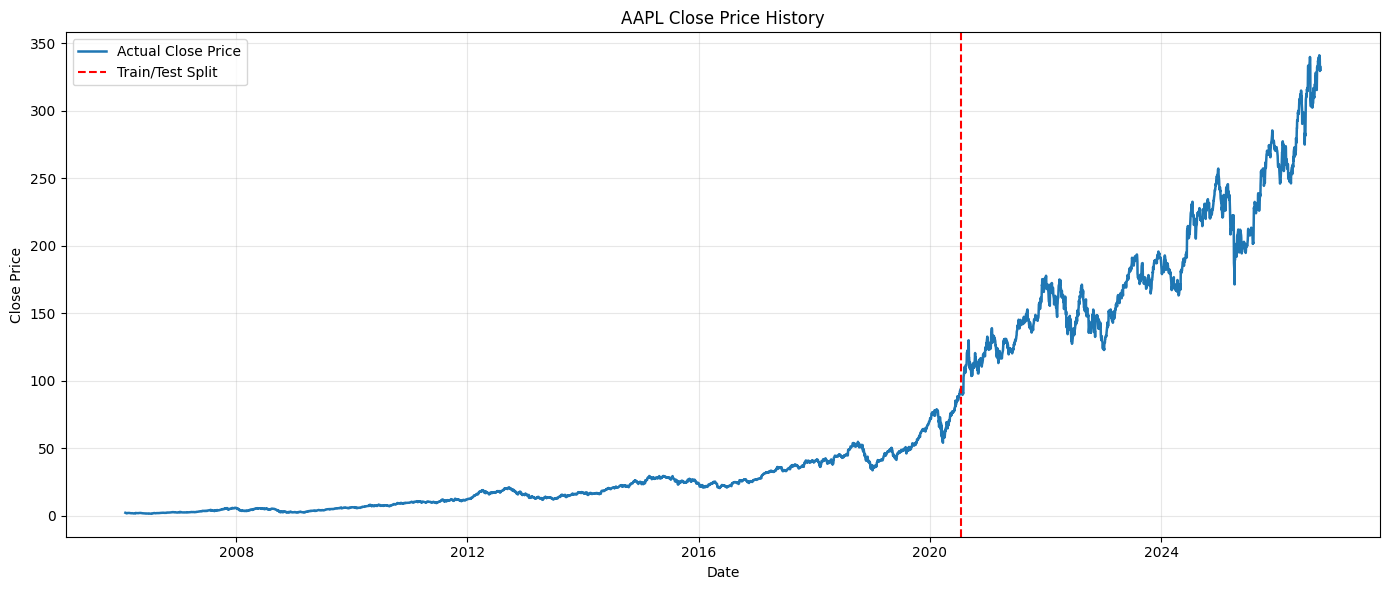

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Actual Close Price", linewidth=1.8)
plt.axvline(dates_test[0], color="red", linestyle="--", label="Train/Test Split")
plt.title(f"{TICKER} Close Price History")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

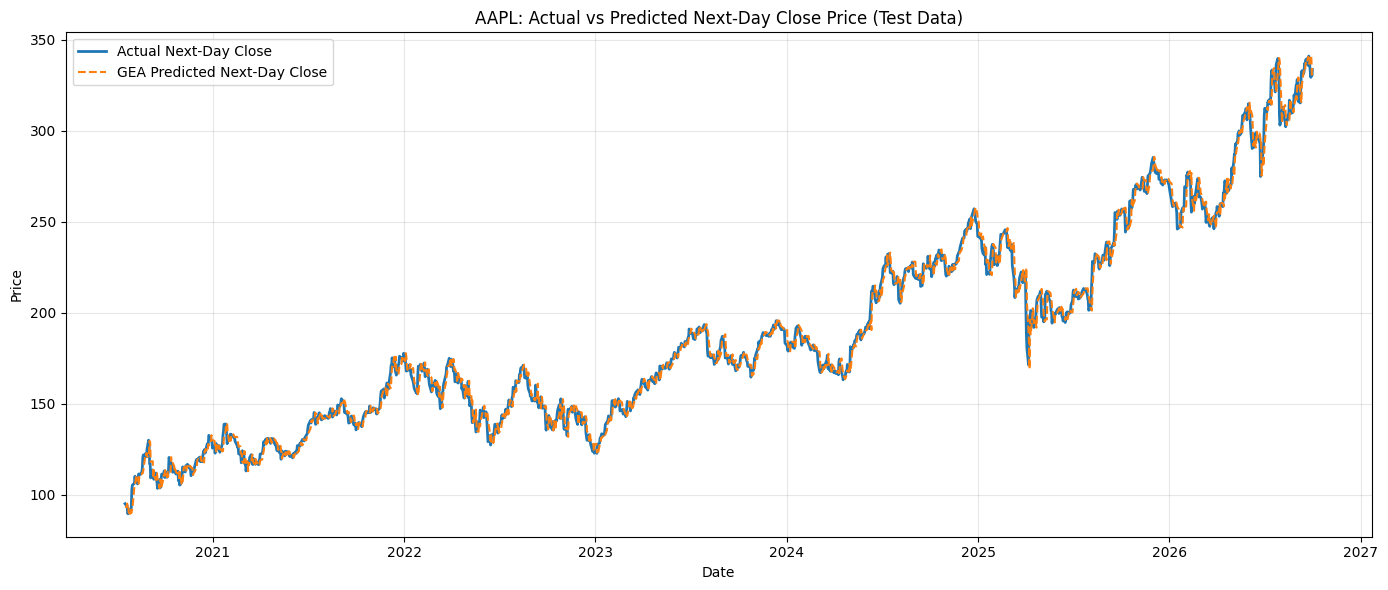

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test, label="Actual Next-Day Close", linewidth=2)
plt.plot(dates_test, test_predictions, label="GEA Predicted Next-Day Close", linestyle="--")
plt.title(f"{TICKER}: Actual vs Predicted Next-Day Close Price (Test Data)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

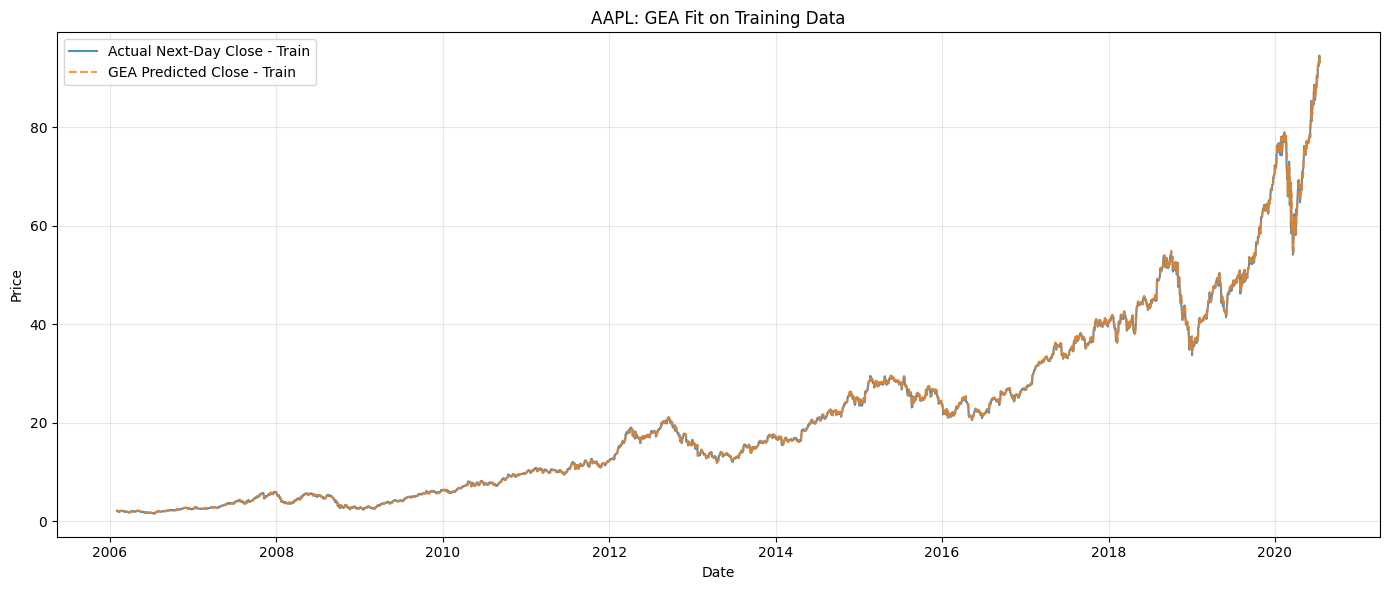

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(dates_train, y_train, label="Actual Next-Day Close - Train", linewidth=1.5, alpha=0.8)
plt.plot(dates_train, train_predictions, label="GEA Predicted Close - Train", linewidth=1.5, linestyle="--", alpha=0.8)
plt.title(f"{TICKER}: GEA Fit on Training Data")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Prediction error visualization

This plot shows the difference between predicted and actual next-day close prices on the test set.


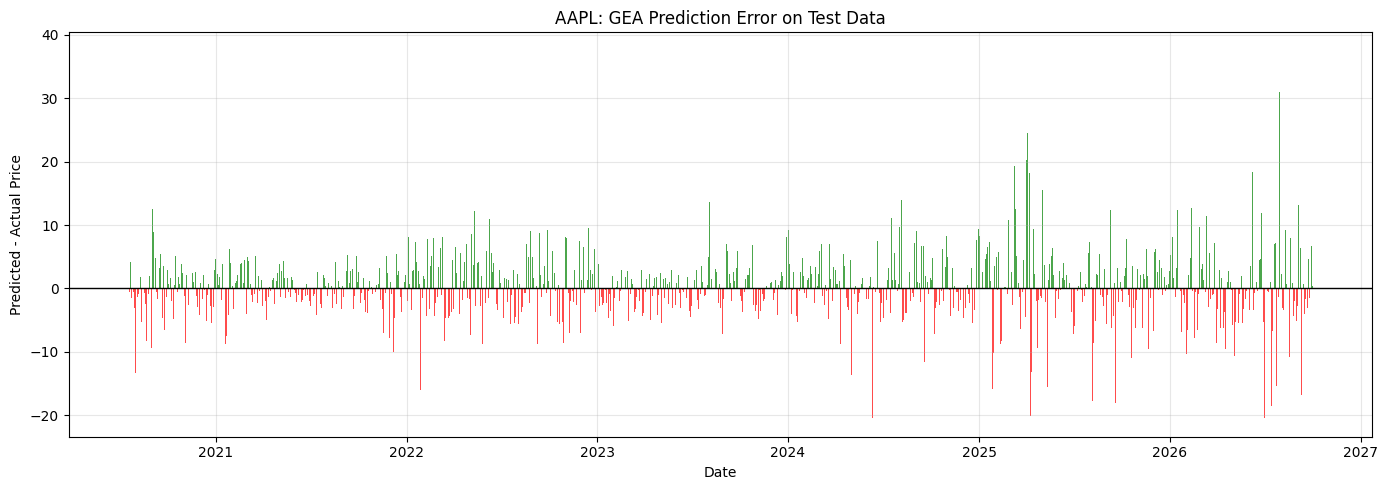

,Date,Actual_Next_Close,Predicted_Next_Close,Error,Absolute_Error
1550,2026-09-18,338.980011,337.291922,-1.688089,1.688089
1551,2026-09-21,339.750000,336.691153,-3.058847,3.058847
1552,2026-09-22,337.019989,339.644219,2.624230,2.624230
1553,2026-09-23,335.920013,340.618604,4.698590,4.698590
1554,2026-09-24,341.070007,337.896039,-3.173968,3.173968
1555,2026-09-25,338.399994,336.826903,-1.573091,1.573091
1556,2026-09-28,329.399994,341.525070,12.125076,12.125076
1557,2026-09-29,333.019989,339.757635,6.737646,6.737646
1558,2026-09-30,330.320007,330.836284,0.516277,0.516277
1559,2026-10-01,333.690002,334.054083,0.364081,0.364081


In [ ]:
errors = test_predictions - y_test

plt.figure(figsize=(14, 5))
plt.bar(dates_test, errors, width=1.0, color=np.where(errors >= 0, "green", "red"), alpha=0.7)
plt.axhline(0, color="black", linewidth=1)
plt.title(f"{TICKER}: GEA Prediction Error on Test Data")
plt.xlabel("Date")
plt.ylabel("Predicted - Actual Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

error_df = pd.DataFrame({
    "Date": dates_test,
    "Actual_Next_Close": y_test,
    "Predicted_Next_Close": test_predictions,
    "Error": errors,
    "Absolute_Error": np.abs(errors)
})

error_df.tail(10)

In [ ]:
error_df['Absolute_Error'].describe()

,Absolute_Error
count,1560.000000
mean,3.537760
std,3.543993
min,0.000743
25%,1.154942
50%,2.605770
75%,4.784638
max,37.497503


In [ ]:
error_df.tail()

,Date,Actual_Next_Close,Predicted_Next_Close,Error,Absolute_Error
1555,2026-09-25,338.399994,336.826903,-1.573091,1.573091
1556,2026-09-28,329.399994,341.525070,12.125076,12.125076
1557,2026-09-29,333.019989,339.757635,6.737646,6.737646
1558,2026-09-30,330.320007,330.836284,0.516277,0.516277
1559,2026-10-01,333.690002,334.054083,0.364081,0.364081


## 13. Save predictions

This creates a CSV containing dates, actual prices, GEA predictions, and errors.


In [ ]:
output_path = f"{TICKER.replace('^', '').replace('.', '_')}_gea_predictions.csv"
error_df.to_csv(output_path, index=False)

print(f"Saved predictions to: {output_path}")
error_df.head()

Saved predictions to: AAPL_gea_predictions.csv


,Date,Actual_Next_Close,Predicted_Next_Close,Error,Absolute_Error
0,2020-07-17,95.150398,93.464642,-1.685756,1.685756
1,2020-07-20,93.837166,93.324962,-0.512204,0.512204
2,2020-07-21,94.100800,95.194932,1.094132,1.094132
3,2020-07-22,89.817657,93.985506,4.167848,4.167848
4,2020-07-23,89.595161,94.640758,5.045597,5.045597


## 14. How to experiment

Try changing these values:

| Setting | What to try | Effect |
|---|---|---|
| `TICKER` | `AAPL`, `TSLA`, `INFY.NS`, `RELIANCE.NS`, `^NSEI` | Tests different markets and assets |
| `GENERATIONS` | 30, 60, 120 | More evolution may improve fit but increases overfitting risk |
| `POP_SIZE` | 40, 80, 150 | Larger populations explore more solutions |
| `MUTATION_RATE` | 0.10, 0.25, 0.40 | Higher mutation increases exploration |
| `TEST_SIZE` | 0.1, 0.2, 0.3 | Changes how much recent data is held out |
| `GENES_PER_INDIVIDUAL` | 3, 6, 10 | More genes allow more complex expressions |

## 15. Important limitations

- A GEA can easily overfit historical price patterns.
- Next-day close prediction is extremely difficult; small errors can look good numerically but may not be tradable.
- This notebook does not include transaction costs, slippage, market impact, or execution constraints.
- Always use walk-forward validation before considering any real trading application.
